# Audio Timbre Sorting with Spectral Centroid

This notebook loads audio files, computes their spectral centroid (a measure of brightness/timbre), sorts them, and provides an interactive slider to navigate through the sorted sounds.

In [1]:
# Import necessary libraries
import librosa
import numpy as np
import os
from pathlib import Path
import IPython.display as ipd
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt

## Step 1: Load Audio Files

Specify the folder containing your audio files. Supported formats: .wav, .mp3, .flac, .ogg

In [2]:
# Specify your audio folder path
audio_folder = "sounds"  # Change this to your folder path

# Get all audio files
audio_extensions = ['.wav', '.mp3', '.flac', '.ogg', '.aiff', '.aif']
audio_files = []

if os.path.exists(audio_folder):
    for ext in audio_extensions:
        audio_files.extend(list(Path(audio_folder).glob(f'*{ext}')))
        audio_files.extend(list(Path(audio_folder).glob(f'*{ext.upper()}')))
    
    audio_files = sorted([str(f) for f in audio_files])
    print(f"Found {len(audio_files)} audio files:")
    for i, file in enumerate(audio_files[:10], 1):
        print(f"  {i}. {Path(file).name}")
    if len(audio_files) > 10:
        print(f"  ... and {len(audio_files) - 10} more")
else:
    print(f"Folder '{audio_folder}' not found. Please create it and add audio files.")

Found 14 audio files:
  1. Bongo C78 Hi.aif
  2. Bongo C78 Low.aif
  3. Clave C78.aif
  4. Cowbell C78.aif
  5. Cymbal C78.aif
  6. Guiro C78 Long.aif
  7. Guiro C78 Short b.aif
  8. Guiro C78 Short.aif
  9. Hihat Closed C78.aif
  10. Kick C78.aif
  ... and 4 more


## Step 2: Compute Spectral Centroid

The spectral centroid represents the "center of mass" of the spectrum - higher values indicate brighter sounds.

In [3]:
# Compute spectral centroid for each audio file
audio_features = []

for audio_file in audio_files:
    try:
        # Load audio file
        y, sr = librosa.load(audio_file, sr=None)
        
        # Compute spectral centroid
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
        
        # Take the mean spectral centroid across time
        mean_centroid = np.mean(spectral_centroid)
        
        audio_features.append({
            'file': audio_file,
            'filename': Path(audio_file).name,
            'spectral_centroid': mean_centroid,
            'y': y,
            'sr': sr
        })
        
        print(f"Processed: {Path(audio_file).name} - Centroid: {mean_centroid:.2f} Hz")
    except Exception as e:
        print(f"Error processing {audio_file}: {e}")

print(f"\nSuccessfully processed {len(audio_features)} files.")

Processed: Bongo C78 Hi.aif - Centroid: 3059.29 Hz
Processed: Bongo C78 Low.aif - Centroid: 5116.07 Hz
Processed: Clave C78.aif - Centroid: 10992.24 Hz
Processed: Cowbell C78.aif - Centroid: 2532.93 Hz
Processed: Cymbal C78.aif - Centroid: 14097.38 Hz
Processed: Guiro C78 Long.aif - Centroid: 11861.35 Hz
Processed: Guiro C78 Short b.aif - Centroid: 12239.48 Hz
Processed: Guiro C78 Short.aif - Centroid: 11897.14 Hz
Processed: Hihat Closed C78.aif - Centroid: 13803.63 Hz
Processed: Kick C78.aif - Centroid: 7986.55 Hz
Processed: Metallic C78.aif - Centroid: 9849.78 Hz
Processed: Rim C78.aif - Centroid: 8100.06 Hz
Processed: Snare C78.aif - Centroid: 13018.12 Hz
Processed: Tamb C78.aif - Centroid: 10214.22 Hz

Successfully processed 14 files.


/Users/ash/Documents/GitHub/Timbre-Slider/.venv/lib/python3.14/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1661
  warnings.warn(


## Step 3: Sort by Spectral Centroid

Sort sounds from darkest (lowest centroid) to brightest (highest centroid).

Sounds sorted by spectral centroid (dark → bright):

 1. Cowbell C78.aif                          | Centroid:  2532.93 Hz
 2. Bongo C78 Hi.aif                         | Centroid:  3059.29 Hz
 3. Bongo C78 Low.aif                        | Centroid:  5116.07 Hz
 4. Kick C78.aif                             | Centroid:  7986.55 Hz
 5. Rim C78.aif                              | Centroid:  8100.06 Hz
 6. Metallic C78.aif                         | Centroid:  9849.78 Hz
 7. Tamb C78.aif                             | Centroid: 10214.22 Hz
 8. Clave C78.aif                            | Centroid: 10992.24 Hz
 9. Guiro C78 Long.aif                       | Centroid: 11861.35 Hz
10. Guiro C78 Short.aif                      | Centroid: 11897.14 Hz
11. Guiro C78 Short b.aif                    | Centroid: 12239.48 Hz
12. Snare C78.aif                            | Centroid: 13018.12 Hz
13. Hihat Closed C78.aif                     | Centroid: 13803.63 Hz
14. Cymbal C78.aif                           | Cen

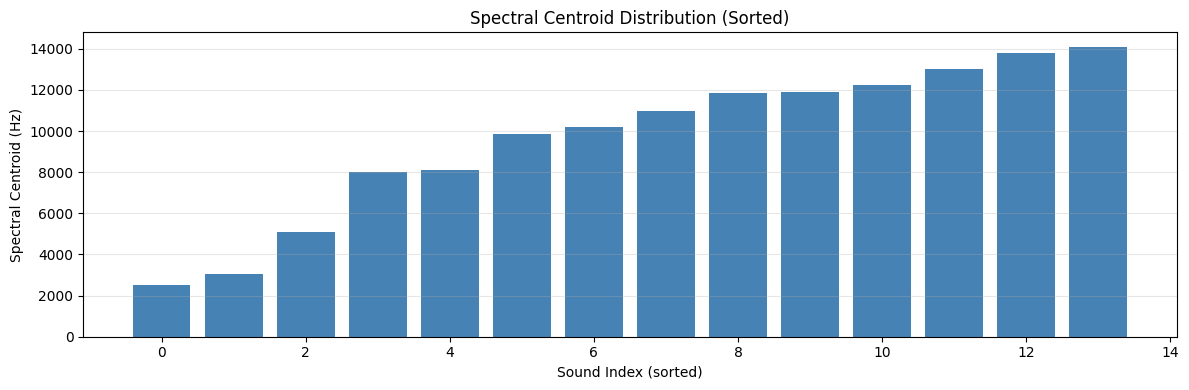

In [4]:
# Sort by spectral centroid
sorted_audio = sorted(audio_features, key=lambda x: x['spectral_centroid'])

# Display the sorted list
print("Sounds sorted by spectral centroid (dark → bright):\n")
for i, audio_info in enumerate(sorted_audio, 1):
    print(f"{i:2d}. {audio_info['filename']:40s} | Centroid: {audio_info['spectral_centroid']:8.2f} Hz")

# Visualize the distribution
plt.figure(figsize=(12, 4))
centroids = [a['spectral_centroid'] for a in sorted_audio]
plt.bar(range(len(centroids)), centroids, color='steelblue')
plt.xlabel('Sound Index (sorted)')
plt.ylabel('Spectral Centroid (Hz)')
plt.title('Spectral Centroid Distribution (Sorted)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: Interactive Slider

Use the slider below to navigate through the sorted sounds. Move from left (dark/low centroid) to right (bright/high centroid).

In [5]:
# Create interactive slider to play sorted sounds
def play_sound(index):
    if len(sorted_audio) == 0:
        print("No audio files to play.")
        return
    
    audio_info = sorted_audio[index]
    
    print(f"\n{'='*70}")
    print(f"Position: {index + 1} / {len(sorted_audio)}")
    print(f"File: {audio_info['filename']}")
    print(f"Spectral Centroid: {audio_info['spectral_centroid']:.2f} Hz")
    print(f"{'='*70}\n")
    
    # Display audio player
    display(ipd.Audio(audio_info['y'], rate=audio_info['sr']))
    
    # Show waveform
    plt.figure(figsize=(12, 3))
    plt.plot(np.linspace(0, len(audio_info['y'])/audio_info['sr'], len(audio_info['y'])), 
             audio_info['y'], linewidth=0.5)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title(f"Waveform: {audio_info['filename']}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if len(sorted_audio) > 0:
    # Create slider
    print('showing sounds')
    interact(play_sound, 
             index=IntSlider(min=0, 
                            max=len(sorted_audio)-1, 
                            step=1, 
                            value=0, 
                            description='Sound:',
                            continuous_update=False))
else:
    print("No audio files loaded. Please check your audio folder.")

showing sounds


interactive(children=(IntSlider(value=0, continuous_update=False, description='Sound:', max=13), Output()), _d…